# OSM

 - [Wiki Overpass API](https://wiki.openstreetmap.org/wiki/Overpass_API#Building_blocks)
 - [Python Overpass API](https://python-overpy.readthedocs.io/en/latest/example.html)
 - [Loading data from OSM with Python and the Overpass API](https://towardsdatascience.com/loading-data-from-openstreetmap-with-python-and-the-overpass-api-513882a27fd0)
 - [PyGIS - Accessing OSM data in python](https://pygis.io/docs/d_access_osm.html)
 - [OSM tags Wiki](https://wiki.openstreetmap.org/wiki/Tags)
 - [OSM and urban data, in book "Geospatial Analysis with Python and R"](https://kodu.ut.ee/~kmoch/geopython2021/L4/osm-urban.html)

### Load

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %load import.py
#
from IPython.display import IFrame

# 
import numpy as np
import pandas as pd

#
from sentinelsat import SentinelAPI, read_geojson, geojson_to_wkt
from datetime import date

#
import rioxarray
import geopandas as gpd
import rasterio as rio

#
from matplotlib import pyplot
from rasterio.plot import show

#
from sqlalchemy import create_engine # query PostGIS
from sqlalchemy import inspect

#
import osmnx as ox

#
from shapely.geometry import Polygon, box
import shapely.ops as so

#
import json

#
import os
from pathlib import Path
import fnmatch
import glob

#
from osgeo import gdal

#
import random

#
import shutil

#
from tqdm import tqdm
import time

#
import folium
from folium import plugins

## Retrieve tags

### Get BBox from Selected Products

#### Load GeoDF

In [64]:
sel_prod_gdf = geopandas.read_file("sel_products.geojson")

#### Check GeoDF

In [34]:
sel_prod_gdf

,title,link,link_alternative,link_icon,summary,ondemand,datatakesensingstart,generationdate,beginposition,endposition,...,producttype,platformidentifier,orbitdirection,platformserialidentifier,processinglevel,datastripidentifier,granuleidentifier,identifier,uuid,geometry
248a17ee-f48b-4ea9-9b3b-4019387f1d05,S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_2...,https://apihub.copernicus.eu/apihub/odata/v1/P...,https://apihub.copernicus.eu/apihub/odata/v1/P...,https://apihub.copernicus.eu/apihub/odata/v1/P...,"Date: 2023-04-27T09:50:31.024Z, Instrument: MS...",false,2023-04-27 09:50:31.024,2023-04-27 11:50:04,2023-04-27 09:50:31.024,2023-04-27 09:50:31.024,...,S2MSI1C,2015-028A,DESCENDING,Sentinel-2A,Level-1C,S2A_OPER_MSI_L1C_DS_2APS_20230427T115004_S2023...,S2A_OPER_MSI_L1C_TL_2APS_20230427T115004_A0409...,S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_2...,248a17ee-f48b-4ea9-9b3b-4019387f1d05,"MULTIPOLYGON (((13.81838 40.55671, 15.11529 40..."


In [35]:
type(sel_prod_gdf)

geopandas.geodataframe.GeoDataFrame

### TAGS definition

#### Buildings

In [71]:
# List key-value pairs for tags
tags = {'building': True}   

### Convert GeoDataFrame geometry (polygon / multipolygon) into Shapely polygon

#### Use the Products bounding box | too large | <i style="color:magenta">not working</b>

In [39]:
x,y = sel_prod_gdf.explode(index_parts=False).geometry[0].exterior.coords.xy

In [40]:
sel_prod_pol = Polygon(list(zip(x, y)))

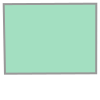

In [41]:
sel_prod_pol

Retrieve OSM data

In [ ]:
osm_data = ox.geometries_from_polygon( sel_prod_pol, tags )

Save OSM data

In [ ]:
osm_data.to_file("osm_data/buildings.geojson", driver='GeoJSON')

#### Use the Study Area bounding box | smaller | <i style="color:magenta">not working</b>

In [42]:
x,y = sa.explode(index_parts=False).geometry[0].exterior.coords.xy

In [43]:
sel_prod_pol = Polygon(list(zip(x, y)))

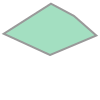

In [44]:
sel_prod_pol

Retrieve OSM data

In [ ]:
osm_data = ox.geometries_from_polygon( sel_prod_pol, tags )

Save OSM data

In [ ]:
osm_data.to_file("osm_data/buildings.geojson", driver='GeoJSON')

### Use PostGIS cities within Products bounding box

#### Retrieve OSM data

In [72]:
osm_data = ox.geometries_from_place( cities_gdf["nuts_name"][0], tags )

/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: >

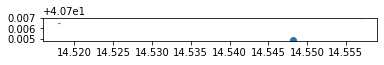

In [79]:
osm_data.head(3).plot()

In [76]:
osm_data.head(3)

/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


addr:city addr:housenumber addr:postcode  \
element_type osmid                                                 
node         3203492696   Lettere               52         80050   
way          314351905        NaN              NaN           NaN   
             346916010        NaN              NaN           NaN   

                          addr:street building                    name  \
element_type osmid                                                       
node         3203492696  Via Conserve    hotel               Meridiana   
way          314351905            NaN      yes  Pizzeria O' Zi Aniello   
             346916010            NaN      yes                     NaN   

                                                     website  \
element_type osmid                                             
node         3203492696  https://www.meridianagrandhotel.it/   
way          314351905                         ozianiello.it   
             346916010                                   NaN   

                                                                  geometry  \
element_type osmid                                                           
node         3203492696                          POINT (14.54814 40.70489)   
way          314351905   POLYGON ((14.51785 40.70649, 14.51817 40.70656...   
             346916010   POLYGON ((14.55703 40.70691, 14.55711 40.70691...   

                                                                     nodes  \
element_type osmid                                                           
node         3203492696                                                NaN   
way          314351905   [3203965954, 3203965955, 3203965956, 320396595...   
             346916010   [3533627201, 3533627202, 3533627203, 353362720...   

                            amenity  ... religion roof:shape wikidata  \
element_type osmid                   ...                                
node         3203492696         NaN  ...      NaN        NaN      NaN   
way          314351905   restaurant  ...      NaN        NaN      NaN   
             346916010          NaN  ...      NaN        NaN      NaN   

                        wikipedia man_made tower:type area building:condition  \
element_type osmid                                                              
node         3203492696       NaN      NaN        NaN  NaN                NaN   
way          314351905        NaN      NaN        NaN  NaN                NaN   
             346916010        NaN      NaN        NaN  NaN                NaN   

                        ways type  
element_type osmid                 
node         3203492696  NaN  NaN  
way          314351905   NaN  NaN  
             346916010   NaN  NaN  

[3 rows x 24 columns]

#### Save OSM data

In [81]:
fname = "osm_data/buildings__" + cities_gdf["nuts_name"][0] + ".geojson"
osm_data.to_file( fname, driver='GeoJSON' )

/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### OSM data :: BATCH retrieve + save

In [131]:
dir_osmdata = "osm_data/"

In [133]:
tags

{'building': True}

In [168]:
osm_data = ox.geometries_from_place( 'Moschiano', tags )

/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [170]:
len(osm_data)

/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


0

In [174]:
for row, fields in cities_gdf.iterrows():
    Found = False
    for filename in os.listdir( dir_osmdata ):
        if filename.startswith( "buildings__" ):
            if fnmatch.fnmatch( filename, 'buildings__' + fields[0] + '.geojson' ):
                print( "%04d" % row, "%40s" % fields[0], '  [existent]')
                Found = True
    if not Found:
        try:
            print( "%04d" % row, "%40s" % fields[0], '  [downloading]' )
            osm_data = ox.geometries_from_place( fields[0], tags )
            if not len(osm_data)==0:
                fname = dir_osmdata + "buildings__" + fields[0] + ".geojson"
                osm_data.to_file( fname, driver='GeoJSON' )
            else:
                print("%45s" % "Skipped because it's empty.")
        except OSError as err:
            print("  OS error:", err)
        except ValueError:
            print("%45s" % "Could not find.")
        except Exception as err:
            print(f"  Unexpected {err=}, {type(err)=}")
            raise

/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


0062                        Montoro Superiore   [downloading]
                              Could not find.
0063                                Moschiano   [downloading]
                  Skipped because it's empty.
0104                                    Sarno   [downloading]
0110                         Procida_alta_ris   [downloading]
                              Could not find.
0121                                 Frignano   [downloading]
                  Skipped because it's empty.
0178                                   Ischia   [downloading]


/home/jovyan/.rsm-msba/lib/python3.8/site-packages/osmnx/geometries.py:805: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):
/home/jovyan/.rsm-msba/lib/python3.8/site-packages/osmnx/geometries.py:805: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):


#### OSM data :: MANUAL psql insert

In [268]:
dir_osmdata = "osm_data/"
tag = "buildings"
CRS = 4326
geom_used = ["Polygon", "MultiPolygon"]

In [320]:
filename = 'buildings__Afragola.geojson'

In [321]:
city = filename.split("__")[1].split(".geo")[0]
city

'Afragola'

In [322]:
#tmp = geopandas.read_file("osm_data/buildings__Lettere.geojson")
tmp = geopandas.read_file( dir_osmdata + filename )

Skipping field ways: unsupported OGR type: 1


In [284]:
tmp.head(1)

,element_type,osmid,historic,name,amenity,wheelchair,nodes,building,wikidata,office,...,denomination,industrial,ruined,ruins,cooling:method,opening_hours,wikipedia,building:min_level,type,geometry
0,way,240255608,None,None,None,None,"[ 2479946246, 2479946248, 2479946250, 24799462...",yes,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((14.44132 40.97166, 14.44138 40.97166..."


In [323]:
tmp[tmp["addr:city"]==city].shape

(4, 44)

In [286]:
tmp["addr:city"]=city

In [287]:
tmp[tmp["addr:city"]==city].shape

(7036, 45)

In [276]:
geom_types = tmp.geometry.type.unique()
for g in geom_types:
    nrows = tmp[tmp.geometry.type==g].shape[0]
    if g in geom_used:
        print( "  > " + g + " [included %d]" % nrows )
    else:
        print( "  > " + g + " [discarded] %d]" % nrows )
        tmp = tmp.drop( tmp[tmp.geometry.type==g].index )

  > Point [discarded] 1]
  > Polygon [included 1675]


In [277]:
from impervious.config import pg_url; db_connection_url = pg_url()
con = create_engine(db_connection_url)

In [312]:
# test connection
inspector = inspect(con)
print( inspector.get_schema_names() )
print( inspector.get_table_names( 'public' ) )

['cron', 'information_schema', 'public', 'topology']
['spatial_ref_sys', 'buildings']


In [313]:
tbl_names = inspector.get_table_names( 'public' )
tbl_names

['spatial_ref_sys', 'buildings']

In [317]:
if tag in tbl_names:
    print('Found table *%s* in db:OSM schema:public' % tag)

Found table *buildings* in db:OSM schema:public


In [280]:
tmp.to_postgis("buildings", con, schema="public", if_exists='append', index=True) #, dtype={'geometry': Geometry('POLYGON', srid=4326)})

#### OSM data :: BATCH psql insert

##### fix issues before I could run the bathc procedure below

ISSUE #01 :: geojson files have different sets of columns

In [ ]:
#contact:housenumber

In [324]:
a = geopandas.read_file("osm_data/buildings__Angri.geojson")
b = geopandas.read_file("osm_data/buildings__Afragola.geojson")

Skipping field ways: unsupported OGR type: 1
Skipping field ways: unsupported OGR type: 1


In [333]:
a.head(1)

,element_type,osmid,amenity,denomination,name,name:etymology:wikidata,religion,wikidata,wikipedia,nodes,...,payment:mastercard,payment:visa,rooms,start_date,layer,ruins,man_made,wikimedia_commons,type,geometry
0,way,96434214,place_of_worship,roman_catholic,Chiesa di Santa Maria del Carmine,Q1065053,christian,Q56268131,it:Chiesa di Santa Maria del Carmine (Angri),"[ 1117469898, 8986535029, 8986535028, 89865350...",...,None,None,None,None,None,None,None,None,None,"POLYGON ((14.57471 40.74037, 14.57471 40.74031..."


In [334]:
b.head(1)

,element_type,osmid,amenity,wheelchair,nodes,brand,brand:wikidata,brand:wikipedia,building,building:levels,...,ruins,indoor,operator:wikidata,power,source,substation,parking,type,addr:postcode,geometry
0,way,121900450,None,yes,"[ 1363448267, 1363448269, 1363448258, 13634482...",IKEA,Q54078,en:IKEA,commercial,2,...,None,None,None,None,None,None,None,None,None,"POLYGON ((14.31557 40.90964, 14.31689 40.90965..."


In [326]:
a.shape

(558, 53)

In [327]:
b.shape

(5360, 44)

In [335]:
ac = list(a.columns)
bc = list(b.columns)

In [337]:
ac

['element_type',
 'osmid',
 'amenity',
 'denomination',
 'name',
 'name:etymology:wikidata',
 'religion',
 'wikidata',
 'wikipedia',
 'nodes',
 'building',
 'castle_type',
 'historic',
 'historic:civilization',
 'website',
 'addr:city',
 'addr:postcode',
 'addr:street',
 'brand',
 'fuel:diesel',
 'operator',
 'ref:mise',
 'source:date',
 'shop',
 'capacity',
 'tourism',
 'addr:housenumber',
 'cuisine',
 'building:levels',
 'healthcare',
 'operator:wikidata',
 'operator:wikipedia',
 'note',
 'phone',
 'smoking',
 'wheelchair',
 'email',
 'internet_access',
 'internet_access:fee',
 'payment:amex',
 'payment:cash',
 'payment:contactless',
 'payment:credit_cards',
 'payment:mastercard',
 'payment:visa',
 'rooms',
 'start_date',
 'layer',
 'ruins',
 'man_made',
 'wikimedia_commons',
 'type',
 'geometry']

In [338]:
bc

['element_type',
 'osmid',
 'amenity',
 'wheelchair',
 'nodes',
 'brand',
 'brand:wikidata',
 'brand:wikipedia',
 'building',
 'building:levels',
 'contact:housenumber',
 'contact:street',
 'description:it:covid19',
 'name',
 'opening_hours',
 'opening_hours:covid19',
 'operator',
 'ref:vatin',
 'roof:shape',
 'shop',
 'website',
 'addr:city',
 'addr:housenumber',
 'addr:street',
 'layer',
 'phone',
 'cuisine',
 'drive_through',
 'takeaway',
 'height',
 'id',
 'leisure',
 'denomination',
 'religion',
 'ruins',
 'indoor',
 'operator:wikidata',
 'power',
 'source',
 'substation',
 'parking',
 'type',
 'addr:postcode',
 'geometry']

In [340]:
# setxor:
set(ac).symmetric_difference(bc)

{'brand:wikidata',
 'brand:wikipedia',
 'capacity',
 'castle_type',
 'contact:housenumber',
 'contact:street',
 'description:it:covid19',
 'drive_through',
 'email',
 'fuel:diesel',
 'healthcare',
 'height',
 'historic',
 'historic:civilization',
 'id',
 'indoor',
 'internet_access',
 'internet_access:fee',
 'leisure',
 'man_made',
 'name:etymology:wikidata',
 'note',
 'opening_hours',
 'opening_hours:covid19',
 'operator:wikipedia',
 'parking',
 'payment:amex',
 'payment:cash',
 'payment:contactless',
 'payment:credit_cards',
 'payment:mastercard',
 'payment:visa',
 'power',
 'ref:mise',
 'ref:vatin',
 'roof:shape',
 'rooms',
 'smoking',
 'source',
 'source:date',
 'start_date',
 'substation',
 'takeaway',
 'tourism',
 'wikidata',
 'wikimedia_commons',
 'wikipedia'}

**Final remark:**
I decide to keep only few columns to avoid wasting time.

In [341]:
column_used = ['element_type','osmid','nodes','building','addr:city','geometry']

In [343]:
a[column_used].shape

(558, 6)

In [344]:
b[column_used].shape

(5360, 6)

In [377]:
c = b.drop(columns='osmid')

In [346]:
c[column_used].shape

KeyError: "['osmid'] not in index"

In [361]:
c.shape

(5360, 43)

In [354]:
list( set(list(c.columns)) & set(column_used) )

['nodes', 'geometry', 'building', 'element_type', 'addr:city']

In [378]:
# change a | b | c below in *.columns:
if len(list( set(list(c.columns)) & set(column_used) )) < len(column_used):
    print('error')
else:
    print('good')

error


In [380]:
# columns that are missing in c.columns compared to column_used:
not_found = list(set(column_used) - set(c.columns))
not_found

['osmid']

In [381]:
c.insert(loc=len(c.columns),column='osmid',value=None)

In [382]:
# columns that are missing in c.columns compared to column_used:
not_found = list(set(column_used) - set(c.columns))
not_found

[]

In [384]:
c = b.drop(columns=['osmid','nodes'])
not_found = list(set(column_used) - set(c.columns))
print(not_found)
for nf in not_found:
    c.insert(loc=len(c.columns)-1,column=nf,value=None)

not_found = list(set(column_used) - set(c.columns))
print(not_found)

['osmid', 'nodes']
[]


##### Run BATCH

Database pgis-osm installed in docker on Pedometrics-VM

In [318]:
dir_osmdata = "osm_data/"
tag = "buildings"
CRS = 4326
geom_used = ["Polygon", "MultiPolygon"]
column_used = ['element_type','osmid','nodes','building','addr:city','geometry']

In [387]:
row=0
tmp = filename = None

try:
    from impervious.config import pg_url; db_connection_url = pg_url()
    con = create_engine(db_connection_url)
    # test connection
    inspector = inspect(con)
    tbl_names = inspector.get_table_names( 'public' )
    if tag in tbl_names:
        print('Found table *%s* in db:OSM schema:public' % tag)
    else:
        print('Table *%s* not found in db:OSM schema:public' % tag)
except OSError as err:
    print("  OS error:", err)
except ValueError:
    print("%45s" % "Could not connect to postGIS")
except Exception as err:
    print(f"  Unexpected {err=}, {type(err)=}")
    raise


for filename in os.listdir( dir_osmdata ):
    if filename.startswith( tag + "__" ):
        row = row +1
        try:
            print( "%04d" % row, "%40s" % filename, ' ...' )

            # step #00 :: Read geojson
            tmp = geopandas.read_file( dir_osmdata + filename )
            
            # step #01 :: select column names
            not_found = list(set(column_used) - set(tmp.columns))
            for nf in not_found:
                print( "  > add missing column %s" % nf )
                tmp.insert(loc=len(tmp.columns)-1,column=nf,value=None)

            not_found = list(set(column_used) - set(c.columns))
            if not len(not_found)==0:
                print('Tag: %s, City: %s :: skipped for issues on missing columns')
                continue
            
            tmp = tmp[column_used]
            
            # step #02 :: write city name, unfortunately it is often/always missing
            city = filename.split("__")[1].split(".geo")[0]
            tmp["addr:city"]=city
            
            # step 03 :: discard geometries not included in 'geom_used'
            geom_types = tmp.geometry.type.unique()
            for g in geom_types:
                nrows = tmp[tmp.geometry.type==g].shape[0]
                if g in geom_used:
                    print( "  > " + g + " [included %d]" % nrows )
                else:
                    print( "  > " + g + " [discarded] %d]" % nrows )
                    tmp = tmp.drop( tmp[tmp.geometry.type==g].index )

            # step 04 :: write in PostGIS
            tmp.to_postgis(tag, con, schema="public", if_exists='append', index=True)
            
            tmp = None
            print("")

        except OSError as err:
            print("  OS error:", err)
        except ValueError:
            print("%45s" % "Could not PSQL insert")
        except Exception as err:
            print(f"  Unexpected {err=}, {type(err)=}")
            raise

Table *buildings* not found in db:OSM schema:public
0001                buildings__Acerra.geojson  ...


Skipping field ways: unsupported OGR type: 1


  > Polygon [included 7034]
  > MultiPolygon [included 2]


Skipping field ways: unsupported OGR type: 1



0002              buildings__Afragola.geojson  ...
  > Polygon [included 5359]
  > MultiPolygon [included 1]


...

  > Polygon [included 3107]


Skipping field ways: unsupported OGR type: 1



0175              buildings__Visciano.geojson  ...
  > add missing column addr:city
  > Polygon [included 1233]


Skipping field ways: unsupported OGR type: 1



0176                 buildings__Volla.geojson  ...
  > Polygon [included 1933]
  > MultiPolygon [included 1]



#### Reproject OSM data

Read geojson

In [175]:
tmp = geopandas.read_file("osm_data/buildings__Lettere.geojson")

/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
Skipping field ways: unsupported OGR type: 1


Reproject

In [177]:
tmp = tmp.to_crs(32633)

/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Remove possible Point geometries

In [186]:
tmp.geom_type.unique()

array(['Point', 'Polygon'], dtype=object)

Save geojson (overwrite)